# Lecture 4: Pandas

March 10, 2025

## Table of contents

0. Technical notes
1. Recap
2. Pandas :: [https://pandas.pydata.org](https://pandas.pydata.org)
3. Exercises

### Midterm

- 80 minutes in class
- NO artificial intelligence helpers
- open book = lectures, google, stackoverflow

### Project

- slowly start to look for your colleagues (pairs, if somebody super alone group of three)

## Questions related to the course

We are starting Week 4. 

Do you need anything to help with?

What would you improve/what do you miss?

## Recap - NumPy

Questions

### Git + Github:

- Are you familiar with it?
- Have you tried to create a repository?

- `!pip` + alternatives


In [1]:
# !pip install pandas

In [2]:
import sys
import pandas as pd

import numpy as np

In [3]:
print(f'Python version {sys.version}')
print(f'Pandas version {pd.__version__}')

Python version 3.13.11 | packaged by Anaconda, Inc. | (main, Dec 10 2025, 21:21:58) [MSC v.1929 64 bit (AMD64)]
Pandas version 3.0.0


In [ ]:
# handling imports, where python looks for modules
sys.path

## Pandas

**Pandas** is a powerful and widely used open-source data manipulation and analysis library in Python. 
It provides data structures like `DataFrame` and `Series`, which make it easy to work with structured data like tables (like in a spreadsheet or SQL). 
It is built on top of `numpy`, making it efficient for numerical computations.

### Why is `pandas` useful?

1. **Ease of Use**: Pandas makes it straightforward to perform data analysis with a simple, readable syntax. Tasks like filtering data, aggregating results, and reshaping data become much easier than using basic Python constructs.
2. **Data Manipulation**: With `pandas`, you can clean, process, and manipulate data. It offers operations for handling missing data, merging datasets, group-by operations, and more.
3. **Data I/O**: It supports loading data from and writing data to various file formats such as CSV, Excel, JSON, SQL databases, and more.
4. **Efficient Handling**: It provides excellent memory and performance optimization for handling large datasets efficiently, thanks to its underlying use of `numpy`.
5. **Integration with Other Libraries**: Pandas integrates well with other data analysis and machine learning libraries in Python, such as `matplotlib` (for plotting), `scikit-learn` (for ML), and `statsmodels` (for statistical analysis).


### Main Data Structures in `pandas`

1. **Series**: A one-dimensional labeled array that can hold any data type.
2. **DataFrame**: A two-dimensional labeled data structure with columns of potentially different data types.

## Data structures in pandas

### Series
* 1D labeled array able to hold any data type (int, str, float, Python objects, etc.)

In [ ]:
pd.Series([1,-1,1,-1])

In [ ]:
pd.Series([1,-1,1,-1]).index

`data` (in the example above) can be:

* a dict
* a list
* an ndarray
* a scalar value

Examples of from dict and a scalar value below:

In [ ]:
# in case of dictionary
dp = pd.Series({'cat':1, 'dog':2, 'parrot':3})
dp

In [ ]:
dp.index

In [ ]:
dp.values

In [ ]:
dp.loc['cat']

In [ ]:
pd.Series({'cat':1, 'dog':2, 'parrot':3}).index

In [ ]:
pd.Series(np.arange(5), index=['a', 'b', 'c', 'd','e'])

* a key difference between Series/pandas and ndarray: operations between Series automatically align the data based on label

In [ ]:
a = pd.Series({"Vítek": 5, "Martin": 10, "Honza": 0})

b = pd.Series({"Martin": 20, "Honza": 15, "Vítek": 5})

print(f"A:\n{a}\nB:\n{b}")

In [ ]:
a + b # operations are done by index

In [ ]:
a = [5,10,0]
b = [20,15,5]

np.array(a) + np.array(b) # now works as expected

* looping through (value-by-value) usually not necessary, remember the case of np array

In [ ]:
a[0]

In [ ]:
a = pd.Series({"Vítek": 5, "Martin": 10, "Honza": 0})


In [ ]:
a['Vítek']

###  DataFrame

* a 2D labeled data structure with columns of potentially different types
* like a spreadsheet or SQL table, or a dict of Series objects
* the most frequently used pandas object 
* can be created:
    * typically by reading a csv file
    * dict of 1D ndarrays, lists, dicts, Series
    * 2D numpy.ndarray
    * a Series
    * another DataFrame

In [ ]:
pd.DataFrame({"var": [1, 2, 3], "column2": [0, 0, 0]})

In [ ]:
a = pd.DataFrame(
    [{"var": 1, "column2": 0}, {"var": 2, "column2": 0}, {"var": 3, "column2": 0}]
)

In [ ]:
a

In [ ]:
a.columns, a.index

In [ ]:
# from dict of Series
d = {
    "one": pd.Series([1.0, 2.0, 3.0], index=["a", "e", "c"]),
    "two": pd.Series([2.0, 1.0, 3.0, 4.0], index=["b", "a", "c", "d"]),
}

df = pd.DataFrame(d)
df

### Data I/O (in/out)
* CSV, JSON, HTML, Excel, HDF5, SQL, pickle, ...
    * for specific details, see [documentation](https://pandas.pydata.org/pandas-docs/stable/user_guide/io.html)
* `pd.read_csv()` is the workhorse for reading text files
    * large number of params means great flexibility when getting data in
    
We will work with the course evaluation data from FSV.
  * each observation is a response to the following questionare (... hope it reminds you of something)

In [ ]:
# load the "raw" data for one particular year
df = pd.read_csv('04_auxiliary/data_2017_zs.csv', sep = ';', on_bad_lines= 'skip')
df.head(3)

In [ ]:
# df

In [ ]:
type(df.tail(2))

In [ ]:
df.columns

In [ ]:
# raw data have column names in czech, let's rename them
# if you do not want to reassign, you can provide arg. "inplace = True"
df = df.rename(columns = {
    'cislo_dot' : 'number',
    'kod_predm' : 'course_code',
    'nazev_predm' : 'course_title',
    'prednasejici' : 'teachers',
    'cvicici' : 'seminar_leaders',
    't1': 'c_value',
    't2': 'c_improve', 
    'katedra_code' : 'department_code'
})
df.head(2)

In [ ]:
# iterative
df.index

In [ ]:
# set column named "number" to be an index (or you can use "inplace" option again)
df.set_index('number', inplace=True)

In [ ]:
df.head()

In [ ]:
df.shape

In [ ]:
df.ndim

In [ ]:
type(df.course_title)

In [ ]:
# look at the data but refrain from drawing the conclusions
df.head(5)

In [ ]:
# make a copy of original data, so if you mess up, can go back to this
# not that smart when you are working with the large data
df_copy = df.copy(deep = True)

* `pd.DataFrame.copy()`:
    * deep: modifications to the data or indices of the copy will not be reflected in the original object
    * shallow: any changes to the data of the original will be reflected in the shallow copy (and vice versa)

In [ ]:
# try to call it as a function
# df.shape() # it si an attribute not a function
df.shape

In [ ]:
# classical data summarization
df.describe()

In [ ]:
#
df.info() # more detailed info

In [ ]:
# memory usage of each column in bytes (useful when working with the larger datasets)
df.memory_usage()

In [ ]:
df.memory_usage().sum()

In [ ]:
df.memory_usage().sum() / 1024**2 # in MB

In [ ]:
df.memory_usage?

In [ ]:
df.tail(1)

In [ ]:
df.shape

In [ ]:
df.iloc[-1]

* you can treat a DataFrame semantically like a dict of like-indexed Series objects
    * getting, setting, and deleting columns works with the same syntax as the analogous dict operations

## Indexing/Selection

| Operation                      | Syntax        |  Result   |
|--------------------------------|---------------|-----------|
| Select column                  | df[col]       |  Series   |
| Select row by label            | df.loc[label] |  Series   |
| Select row by integer location | df.iloc[loc]  |  Series   |
| Slice rows                     | df[5:10]      | DataFrame |
| Select rows by boolean vector  | df[bool_vec]  | DataFrame |

In [ ]:
# gives us series
df['course_title']

In [ ]:
# this demonstrates usefulness of proper column naming
df.course_title

In [ ]:
# multiple columns -> gives us dataframe
df[['course_title', 'q1']]

In [ ]:
# just one column: just convenience (if column name has a space or dot, you are screwed)
#naming conventions: no special character, underscore for spaces, no CZECH chars! informative and short
df.course_title

In [ ]:
# subset of columns you want 
df[['course_title','teachers']].head(10)

In [ ]:
# list of all columns 
df.columns

In [ ]:
# adding columns (first adding, so we have something to drop)
df['tmp'] = '11/10'
# you can also use assign function, if new column should be a function of original column 
df.head()

In [ ]:
df['sumq1q2'] = df.q1 + df.q2
df.head()

In [ ]:
# drop column (you can also use 'del' (a general python command for deleting)
df.drop('tmp', axis = 1, inplace = True) # axis to specify you want to drop column, inplace operation in this case

In [ ]:
df.head()

In [ ]:
(df.department_code == 'ies') & (df.teachers.str.contains('Baruník'))

In [ ]:
df[(df.department_code == 'ies') & (df.teachers.str.contains('Baruník'))].shape

In [ ]:
df[df.department_code == 'ies']

### Location and Idioms
* `.loc` selects data by the label of the rows and columns (as opposed to the `.iloc`) integer location
* we can also use `.loc` for subsetting based on condition(s)

In [ ]:
df.index

In [ ]:
df.loc[5:25:3, ['department_code','teachers']]

In [ ]:
# df.iloc[5:25:3, [-2, 2]] # iloc is integer based, different from loc which is label based
df[['department_code','teachers']].iloc[5:25:3]

What might be a problematic difference?

#### Subset using a mask

- Masking is a way to filter data by creating a "mask" (boolean array) that indicates which rows or columns should be included in a subset.
- It makes it easy to filter rows based on complex conditions.
- The approach is efficient and readable for selecting subsets of data in pandas.
  1) Create a mask (`True` or `False`)
  2) Apply the mask

In [ ]:
# select only observations for IES only, mask done at once
df_ies = df.loc[df['department_code'] == 'ies']

In [ ]:
df_ies.head()

In [ ]:
(df['course_title'] == 'Advanced Econometrics')

In [ ]:
# select only observations for Advanced Econometrics
df.loc[df['course_title'] == 'Advanced Econometrics'].head(5)

**Using ~ to Invert a Mask**

The tilde (~) symbol is used as a bitwise NOT operator, often applied to invert a boolean mask.

In [ ]:
~(df['course_title'] == 'Advanced Econometrics')

In [ ]:
# sub-setting based on multiple conditions: AE and non-missing comment on what to improve
df.loc[(df['course_title'] == 'Advanced Econometrics') & (~df['c_improve'].isnull())].head(2)

* Sometimes, we don't have a clear list of columns to be selected ready, e.g. how to select columns from q1 to q13? 
    * using actual list of column names :(
        * be lazy!
    * or ... 

In [ ]:
print([x for x in df.columns if "q" in x[:1]])  # by substring

In [ ]:
# list comprehension
print([x for x in df.columns if "q" in x])  # by substring
print([x for x in df.columns if (len(x) == 2) | (len(x) == 3)])  # by length
print([x for x in df.columns if x.startswith("q")])  # by first letter
# by regular expression is the safest - q and then at most 2 digit number -> later in course

In [ ]:
[x for x in df.columns if 'q' in x]

In [ ]:
df_q = df[[x for x in df.columns if 'q' in x]]
df_q.head()

### Using functions on pandas objects

| Operation          | Function              |
|--------------------|-----------------------|
| Row or Column-wise | `apply()`             |
| Aggregation        | `agg() / transform()` |
| Elementwise        | `applymap()`          |

**Tablewise**
* DFs and Series can be arguments of the functions
* if multiple functions need to be called in a sequence, use `pipe()` method, also called the method chaining
    * often used in the data science setting
    * inspired by unix pipes and dplyr (%>%) operator in R 

**Row or Column-wise Function Application**
* `apply()` is extremely powerful, when used with some brainpower

In [ ]:
df_q.apply(np.mean, axis=0)

In [ ]:
df_q.mean(axis=0)

In [ ]:
# using lambda - anonymous function
# standardization to unit variance
df_q.apply(lambda x: (x - np.mean(x)) / np.std(x), axis=0)

In [ ]:
# using custom function, with arguments (could have also be done with lambda)
def add_and_substract(df, sub=1, add=1):
    return df - sub + add


df_q.apply(add_and_substract, args=(1, -1))

In [ ]:
# A little bit more sophisticated:  show the longest comment
df.loc[df["c_value"].apply(lambda x: len(str(x))).idxmax(), ["seminar_leaders", "c_value"]]

In [ ]:
df["c_value"].apply(lambda x: len(str(x))).idxmax()

In [ ]:
pd.DataFrame.idxmax?

In [ ]:
df.loc[df["c_value"].apply(lambda x: len(str(x))).idxmax()]

In [ ]:
df.index[max(df["c_value"].apply(lambda x: len(str(x)))) == df["c_value"].apply(lambda x: len(str(x)))] # alternative to find max and its index

In [ ]:
df.loc[df.index[max(df["c_value"].apply(lambda x: len(str(x)))) == df["c_value"].apply(lambda x: len(str(x)))]] 

**Aggregation**
* *`aggregate()`* and *`transform()`*
* aggregation allows multiple aggregation operations in a single concise way
* `transform()` method returns an object that is indexed the same as the original
   * allows multiple operations at the same time, instead of one-by-one as `aggregate()` method

In [ ]:
# aggregating simple function is the same as apply
df_q.agg(np.mean, axis=0)

In [ ]:
df_q.mean()

In [ ]:
# aggregating more functions more interesting (you could do your own describe function easily! )
df_q.aggregate([np.mean, np.std, np.min, np.max], axis = 0)

In [ ]:
df_q.aggregate([pd.Series.mean, pd.Series.std, pd.Series.min, pd.Series.max], axis=0)

In [ ]:
# aggregating using dictionary, i.e. column specific aggregation 
df_q.agg({'q1' : [np.mean], 'q2': np.std, 'q3': [np.mean, np.std, np.var]})

In [ ]:
# using single function, the same as with apply
df_q.transform(lambda x: np.power(x,2))

In [ ]:
# using multiple functions (can also be done using dictionary as in the case of aggregate)
df_q.transform([np.abs, lambda x: x + 1])

## Missing values

Handling missing values is a common task in data cleaning.

1. Identifying Missing Values
    
    In `pandas`, missing values are usually represented as `NaN` (Not a Number). To identify missing values, you can use:

- `isna()` or `isnull()`: Returns a DataFrame of booleans indicating where values are NaN.
- `notna()` or `notnull()`: Opposite of `isna()`, returns True for non-NaN values.
- `any()` and `sum()`: Combined with `isna()`, they can help you see how many or if any missing values are in each column.

2. Dropping Missing Values

    `dropna()`: Removes rows or columns with missing values.

3. Filling Missing Values
   
   `fillna(value=0)`: Fill `NaN`s with a specified value
   
4. Replacing Specific Values

    `replace("", pd.NA, inplace=True)`: Replace specific values with `NaN`

5. Interpolating Missing Values

    `interpolate()`: Estimates missing values by interpolating the data. You can specify different methods like linear, polynomial, or time.
    
6. Using Conditional Fill

In [ ]:
df.head()

In [ ]:
df.teachers.notnull()

In [ ]:
df.teachers.notnull().sum()

In [ ]:
df.teachers.notnull().sum() / df.shape[0]

In [ ]:
# check for missing values, sum is summing those NA
df.teachers.isna().any(), df.teachers.isna().sum() # isna is alias for isnull

In [ ]:
df[df.teachers.notnull()]

% of missing observations for specific column

In [ ]:
df["q1"].isnull().sum() / df["q1"].count()

% of missing observations for all columns

In [ ]:
(df.isnull().sum() / df.shape[0]).sort_values().plot.bar()

In [ ]:
(df.isnull().sum() / df.shape[0]).sort_values().plot.bar(ylim=(0, 1), grid=True, figsize=(5,3))

In [ ]:
print(df.dropna(subset=['q1', 'q2'], how='any').shape)
df.dropna(subset=['q1', 'q2'], how='any').head()

In [ ]:
df.dropna().shape # drop all rows with any missing value

## Matplotlib <a name="introduction"></a>

[https://matplotlib.org](https://matplotlib.org)

* "A picture is worth a thousand words."
    * more like "A picture is worth a few lines of code."
* development started in 2003 by John D. Hunter, a neurobiologist (inspired by MATLAB software)
* generating basic plots in *matplotlib* is simple, mastering the library can be little bit less pleseant (we skip this part)
* you can have as much control as you want, but you can also concede as much control as you want 
* [**gallery**](https://matplotlib.org/stable/gallery/index.html)
    * can get help to problems like "I want to make a figure that looks something I've seen somewhere." (hard to google)
* plotting consists of many layers, from general 'contour this 2D array' to very specific 'color this screen pixel'
    * key is allowing both levels to coexist in one package
* *matplotlib* has 2 interfaces:
    1. "state-machine environment" (based on MATLAB)
    2. a object-oriented interface
* this often creates confusion (multiple, conflicting, solutions on the web)
* another common confusion is the relationship of *Matplotlib, pyplot and pylab*
    * Matplotlib is the whole package
    * `matplotlib.pyplot` is a module in matplotlib
    * `pylab` is a a convenience module doing a bulk import of `pyplot` and `numpy`

* [anatomy of the plot](https://matplotlib.org/examples/showcase/anatomy.html) from matplotlib

<img src= "https://matplotlib.org/_images/anatomy.png" width= "600" height="400">

* the *figure* keeps track of all the child *Axes*, titles,legends, etc.
    * the figure can have any number of *Axes*
* *Axes* is 'a plot', i.e. the region of the image with the data space
    * given *Axes* object can only be in one Figure
    * *Axes* contains 2 (3 in case of 3D) *Axis* objects which take care of the data limits (conrolled via `set_xlim()` method)
    * each *Axes* has a title (`set_title()`), an x- and y-labels (`set_xlabel()`)
* *Artist* is anything you can see on the figure, e.g. text objects, Line2D objects, etc.

* `matplolib.pyplot` functions make some changes to a figure, e.g. create a figure, plot some lines, etc.
    * the plotting functions are directed to the current axes

* all of plotting functions expect `np.array` or `array-like` data objects (for majority of cases works out of the box)

In [4]:
# !pip install matplotlib

In [5]:
import matplotlib.pyplot as plt
%matplotlib inline

In [6]:
%config InlineBackend.figure_format='retina'

In [7]:
# increasing the size of the figure
plt.figure(figsize = (20,10))

<Figure size 2000x1000 with 0 Axes>

<Figure size 2000x1000 with 0 Axes>

In [8]:
from time import sleep

In [9]:
plt_styles_list = plt.style.available

In [10]:
len(plt_styles_list)

29

In [11]:
# plt_styles_list

Solarize_Light2


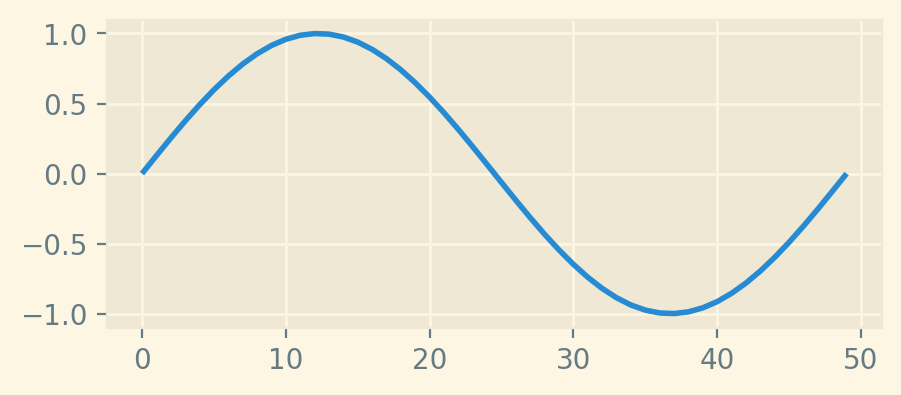

_mpl-gallery


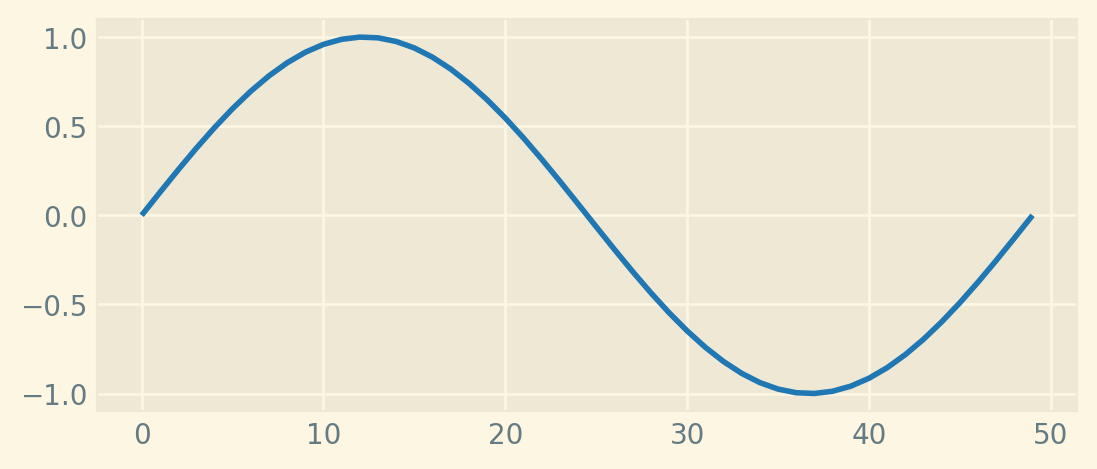

bmh


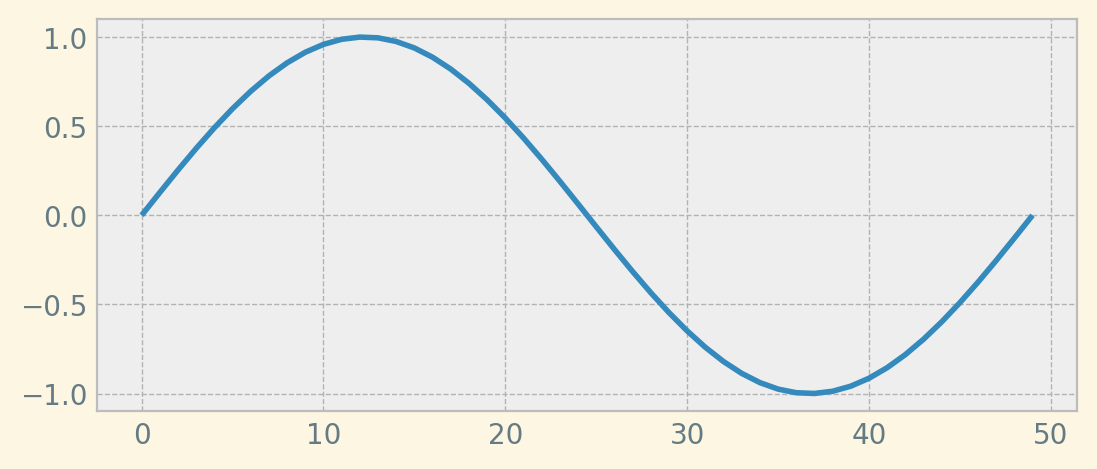

dark_background


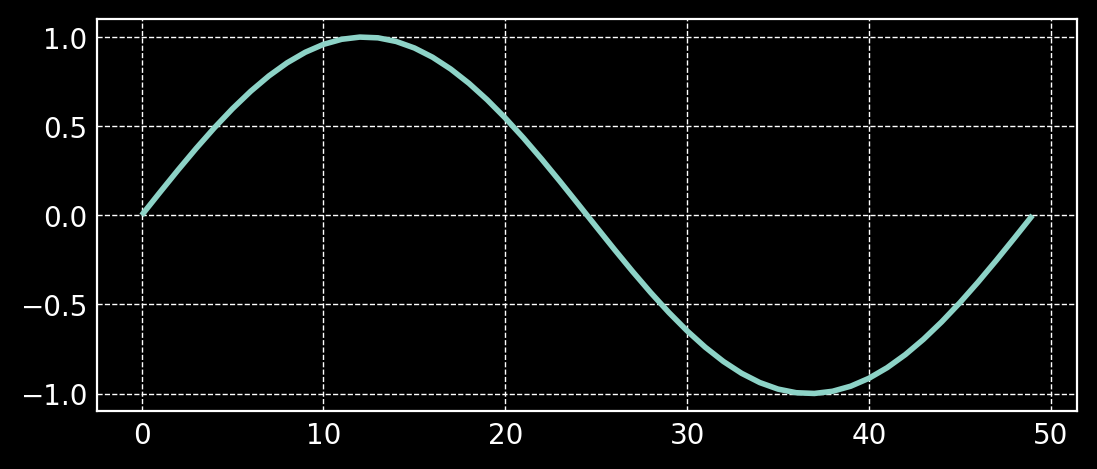

fivethirtyeight


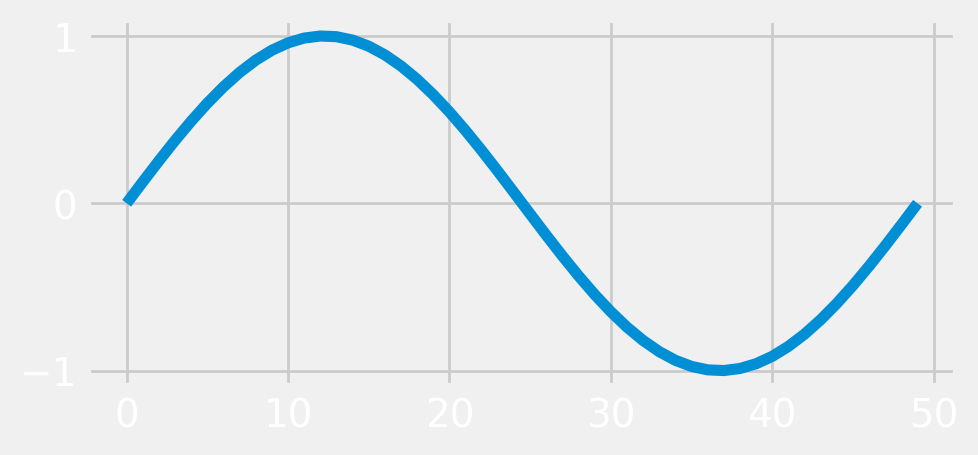

In [12]:
# let's see how different styles look like
for style in plt_styles_list[:10:2]:
    plt.style.use(style)
    print(style)
    plt.figure(figsize=(5,2))
    plt.plot(np.sin(np.linspace(0,2*np.pi)))
    plt.show()
    sleep(1)

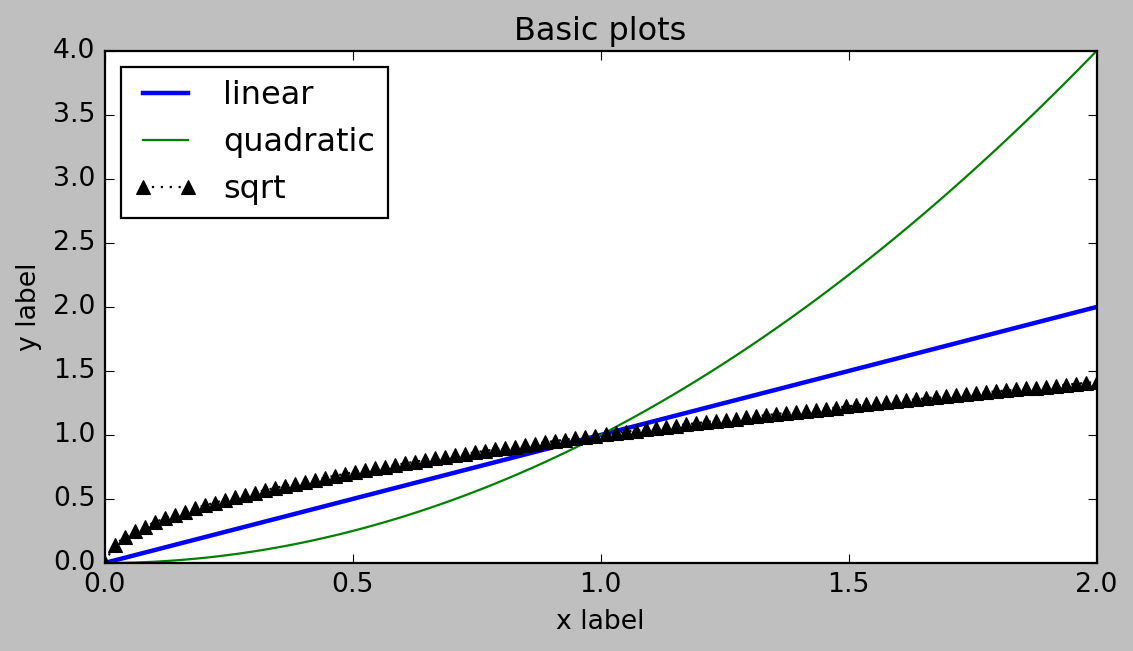

In [17]:
plt.style.use('classic')
# minimum example of pyplot
x = np.linspace(0, 2, 100)

# we can also specify only "y" and use default x-axis: plt.plot(x, label='linear')
plt.figure(figsize=(8,4))
plt.plot(x, x, label='linear',  linewidth=2.0)
plt.plot(x, x**2, label='quadratic')
plt.plot(x, np.sqrt(x),'k^:',label='sqrt')

plt.xlabel('x label')
plt.ylabel('y label')
plt.title("Basic plots")

plt.legend(loc = 'best');

In [18]:
plt

<module 'matplotlib.pyplot' from 'c:\\Users\\jachy\\anaconda3\\envs\\python_data_course\\Lib\\site-packages\\matplotlib\\pyplot.py'>

* for multiple subplots: `fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2, sharey=True, figsize=(7, 4))`
* call `plt.subplot()` and specify three numbers:
    * number of rows
    * number of columns
    * subplot number you want to activate.
* if subplots are too squished `plt.tight_layout()`

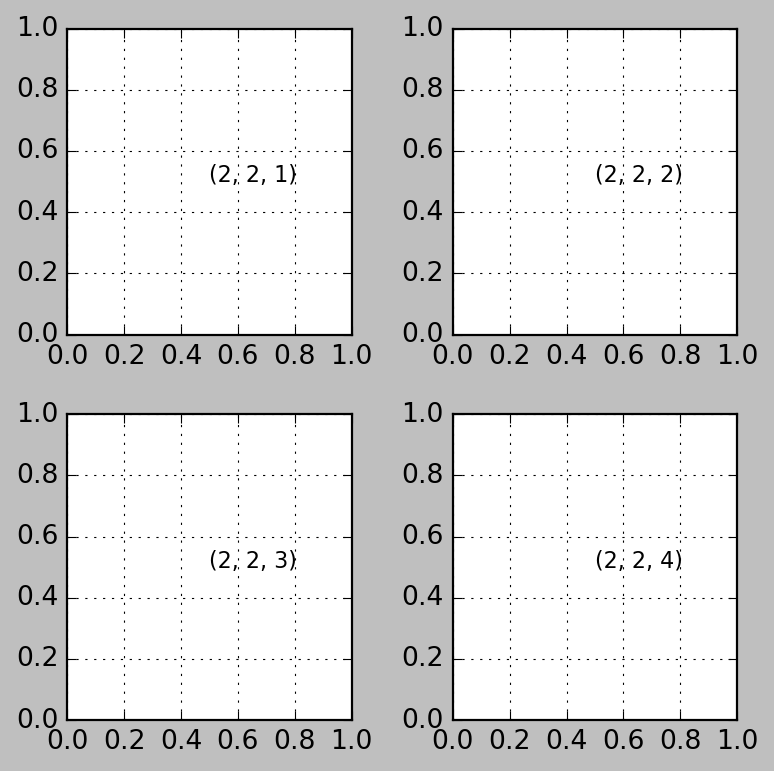

In [19]:
plt.figure(figsize=(5,5))
for i in range (1, 5):
    plt.subplot(2, 2, i)
    plt.text(0.5,0.5, str((2, 2, i)), ha='left', fontsize = 10) #again, just a plot
    plt.tight_layout() 
    plt.grid(True) # add the grid

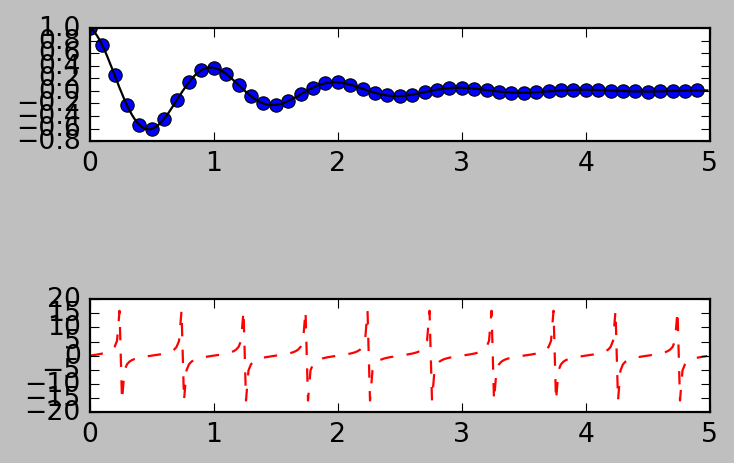

In [20]:
# for multiple figures and axes 

def f(x):
    return np.exp(-x) * np.cos(2*np.pi*x)

x1 = np.arange(0.0, 5.0, 0.1)
x2 = np.arange(0.0, 5.0, 0.02)


plt.figure(1, figsize=(5,3)) # optional, since figure(1) will be created by default
plt.subplot(311)
plt.plot(x1, f(x1), 'bo', x2, f(x2), 'k')

plt.subplot(313)
plt.plot(x2, np.tan(2*np.pi*x2), 'r--')


plt.show()

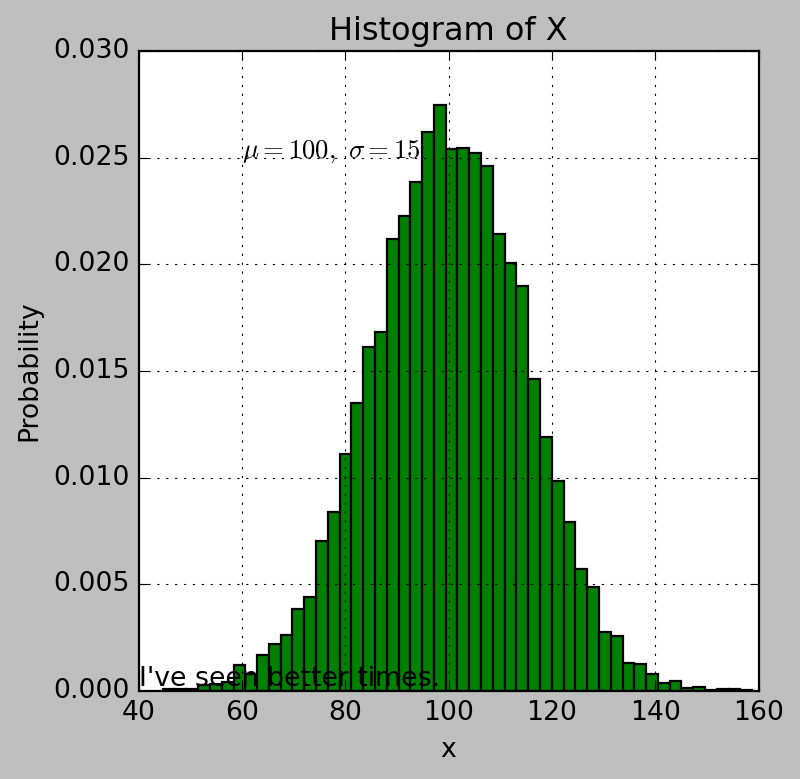

In [21]:
mu, sigma, n = 100, 15, 10000
x = np.random.normal(mu, sigma, n)

plt.figure(figsize=(5,5))
# the histogram of the data
plt.hist(x, bins = 50, density= True, facecolor='g')

plt.xlabel('x')
plt.ylabel('Probability')
plt.title('Histogram of X')

# Adding text, with LaTeX syntax, for math symbols
# meaningful text, 
plt.text(60, .025, rf'$\mu={mu},\ \sigma={sigma}$')
# tail events text
plt.text(40, .00025, f"I've seen better times.")

plt.grid(True)

## Saving plots

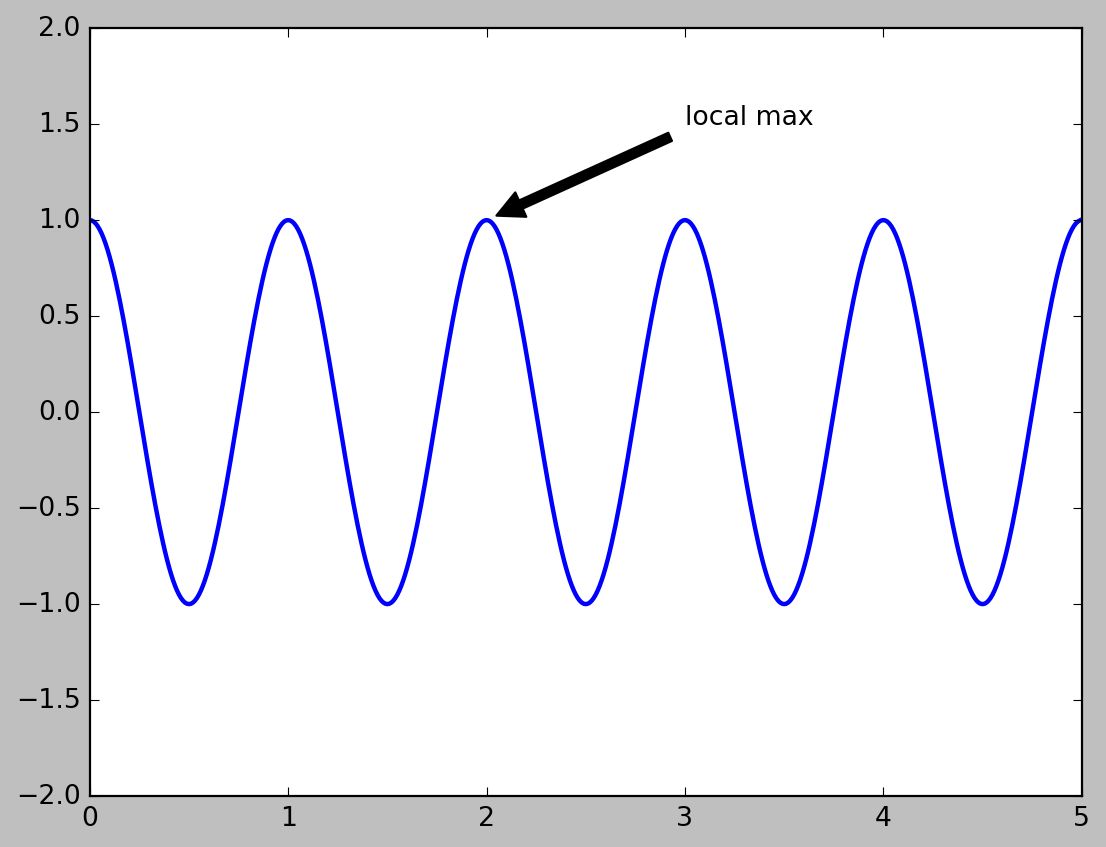

In [22]:
# ax = plt.subplot()
plt.subplot(111)
t = np.arange(0.0, 5.0, 0.01)
s = np.cos(2*np.pi*t)
line, = plt.plot(t, s, lw=2)

plt.annotate('local max', xy=(2, 1), xytext=(3, 1.5),
             arrowprops=dict(facecolor='black', shrink=0.05),
             )

plt.ylim(-2, 2)
# actually saving
plt.savefig('04_auxiliary/local_max.png')

Explanation of fig and ax, you might encounter when working with plots (openAI):

`fig, ax = plt.subplots()` or `fig, ax = plt.figure()` is a common syntax used for creating plots with control over the `figure` and its `axes`.

`fig, ax = plt.subplots()`

`fig`: The canvas, representing the whole figure, where you set properties affecting all subplots.

`ax` or `axes`: The individual plot areas (one or more Axes) within the figure, where you do the actual plotting and customization.

In [23]:
plt.style.use('ggplot')

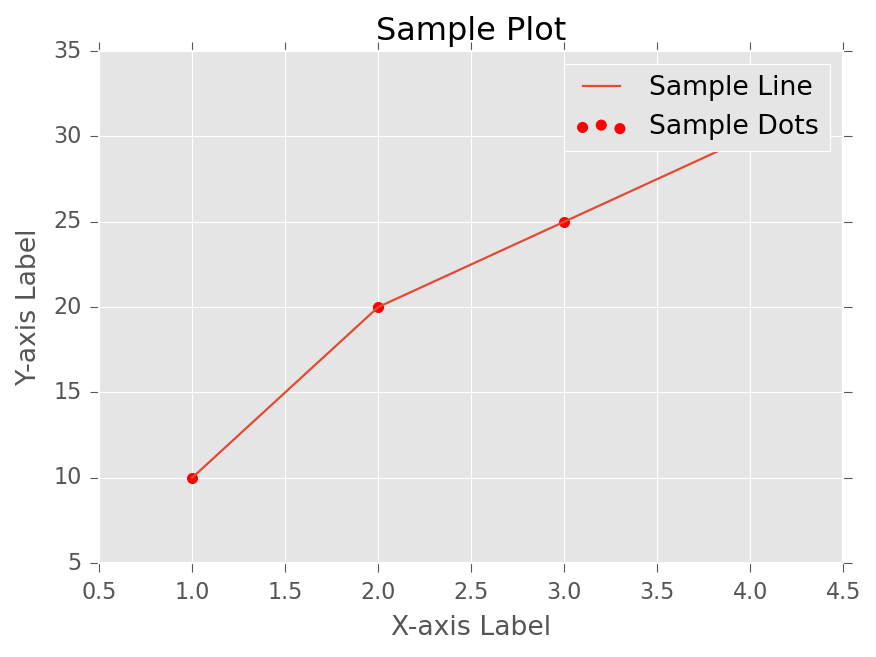

In [24]:
# Example
import matplotlib.pyplot as plt

# Create a figure with a single Axes
fig, ax = plt.subplots(figsize=(6, 4))  # figsize the size of the figure in inches

# Plot data on the Axes
ax.plot([1, 2, 3, 4], [10, 20, 25, 30], label='Sample Line')

ax.scatter([1, 2, 3, 4], [10, 20, 25, 30], label='Sample Dots', color='red')

# Customize the Axes
ax.set_title('Sample Plot')
ax.set_xlabel('X-axis Label')
ax.set_ylabel('Y-axis Label')
ax.legend()

# Show the figure
plt.show()